## Prediksi Ambang Batas NO2 Satu Hari Kedepan

Pada tugas kali ini bertujuan untuk memprediksi apakah konsentrasi No2 akan melebihi batas ambang satu hari ke depan, dimana letak lokasi yang saya ambil adalah Sekitas Kamal-Labang, Bangkalan, Madura. Dengan menggunakan data source Sentinel-5p (Copernicus Data Space) dengan metode KNN Classification (Binary: Aman/Berbahaya). Untuk masa periode yang saya ambil adalah Juli 2021- Juli 2022.

### Install OpenEo

In [2]:
pip install openeo


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 12.0 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 50.6 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╺━━━━━━ 5/6 [openeo]]  WARNING: The script openeo-auth is installed in '/usr/local/python/3.12.1/bin' which is not on PATH.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6/6 [openeo]
Note: you may need to restart the kernel to use updated packages.


### Import Library

In [1]:
import openeo
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import time
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_curve, auc,
    roc_auc_score, ConfusionMatrixDisplay
)

sns.set_style("darkgrid")
plt.rcParams['figure.figsize'] = (12, 6)

print("Semua library berhasil diimport")

Semua library berhasil diimport


### Data UnderStanding

### 1.Pengumpulan Data (Data Collection)
Dimana bersumber dari Sentinel-5p via OpenEo (Copernicus Data Space), dan untuk outputnya adalah sebuah file csv dengan data No2 harian untuk periode Juli 2021-Juli 2022.

In [2]:
import openeo
import pandas as pd
import os
import time

print("="*75)
print("LANGKAH 1: PENGUMPULAN DATA NO2 (Sentinel-5P via OpenEO)")
print("="*75)

# 1. Koneksi ke Copernicus Data Space
print("Menghubungkan ke OpenEO DataSpace...")
connection = openeo.connect("openeo.dataspace.copernicus.eu").authenticate_oidc()
print("Koneksi berhasil.\n")

# 2. Area of Interest (AOI) - Bangkalan, Madura
aoi = {
    "type": "Polygon",
    "coordinates": [[
        [112.72039971871624, -7.11744614362911],
        [112.72039971871624, -7.156335253461791],
        [112.78220716761746, -7.156335253461791],
        [112.78220716761746, -7.11744614362911],
        [112.72039971871624, -7.11744614362911],
    ]]
}

# 3. Load data Sentinel-5P
print("Mengambil data Sentinel-5P (band: NO2)...")
s5p = connection.load_collection(
    "SENTINEL_5P_L2",
    spatial_extent={
        "west": 112.72039971871624,
        "south": -7.156335253461791,
        "east": 112.78220716761746,
        "north": -7.11744614362911,
    },
    temporal_extent=["2021-07-01", "2022-07-30"],
    bands=["NO2"],
)

# 4. Mask nilai negatif
def mask_invalid(x):
    return x < 0

s5p_masked = s5p.mask(s5p.apply(mask_invalid))
print("Nilai negatif berhasil dimasking.")

# 5. Agregasi temporal (harian)
daily_mean = s5p_masked.aggregate_temporal_period(period="day", reducer="mean")

# 6. Agregasi spasial (mean dalam AOI)
daily_mean_aoi = daily_mean.aggregate_spatial(geometries=aoi, reducer="mean")
print("Agregasi spasial dan temporal selesai.")

# 7. Jalankan batch job
print("\nMenjalankan batch job di OpenEO...")
job = daily_mean_aoi.create_job(out_format="CSV")
job.start()

print(f"Job berhasil dikirim (Job ID: {job.job_id})")
print("Menunggu job selesai (pengecekan setiap 2 menit)...")

# 8. Monitoring job status
while True:
    status = job.describe()["status"]
    print(f"Status saat ini: {status}")
    if status == "finished":
        print("Job selesai. Mengunduh hasil...")
        break
    elif status == "error":
        raise RuntimeError("Job gagal di server OpenEO.")
    time.sleep(120)  # cek setiap 2 menit

# 9. Unduh hasil
os.makedirs("no2_results", exist_ok=True)
results = job.get_results()
results.download_files("no2_results")

# 10. Baca hasil CSV
csv_files = [f for f in os.listdir("no2_results") if f.endswith(".csv")]
if not csv_files:
    raise FileNotFoundError("Tidak ada file CSV ditemukan di folder hasil.")

df = pd.read_csv(os.path.join("no2_results", csv_files[0]))

# 11. Preprocessing data
df["date"] = pd.to_datetime(df["date"])
df = df.sort_values("date").reset_index(drop=True)
df.to_csv("timeseries.csv", index=False)

# 12. Ringkasan hasil
print("\nDATA BERHASIL DIKUMPULKAN")
print("-" * 60)
print(f"Periode        : {df['date'].min().date()} - {df['date'].max().date()}")
print(f"Total records  : {len(df)}")
print(f"File output    : timeseries.csv")
print("-" * 60)
print("\nData pertama (5 baris):")
print(df.head())


LANGKAH 1: PENGUMPULAN DATA NO2 (Sentinel-5P via OpenEO)
Menghubungkan ke OpenEO DataSpace...
Authenticated using refresh token.
Koneksi berhasil.

Mengambil data Sentinel-5P (band: NO2)...
Nilai negatif berhasil dimasking.
Agregasi spasial dan temporal selesai.

Menjalankan batch job di OpenEO...
Job berhasil dikirim (Job ID: j-2510231958094650b10282890bb0727b)
Menunggu job selesai (pengecekan setiap 2 menit)...
Status saat ini: created
Status saat ini: running
Status saat ini: running
Status saat ini: finished
Job selesai. Mengunduh hasil...

DATA BERHASIL DIKUMPULKAN
------------------------------------------------------------
Periode        : 2021-06-30 - 2022-07-29
Total records  : 395
File output    : timeseries.csv
------------------------------------------------------------

Data pertama (5 baris):
                       date  feature_index       NO2
0 2021-06-30 00:00:00+00:00              0       NaN
1 2021-07-01 00:00:00+00:00              0  0.000041
2 2021-07-02 00:00:00+0

Total records : 395
Periode data  : 2021-06-30 hingga 2022-07-29


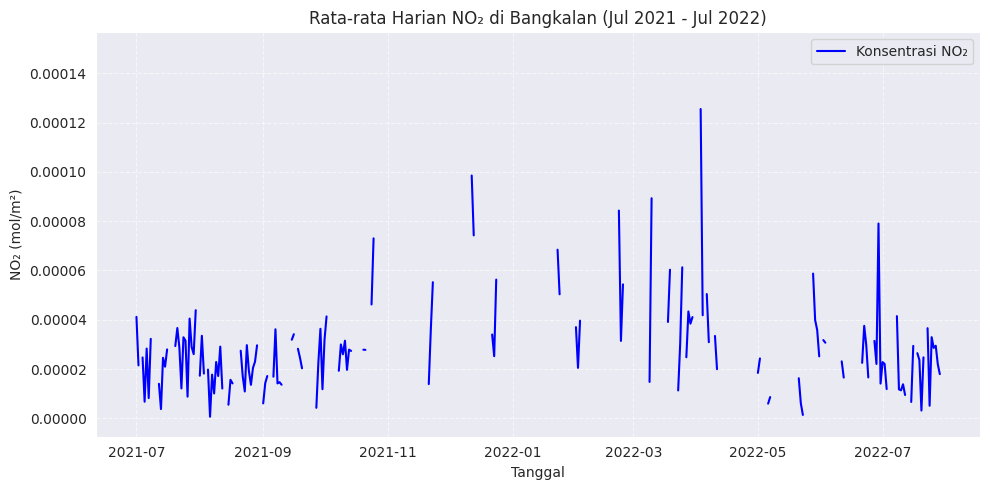

In [13]:
# Baca hasil dari file yang sudah kamu dapat sebelumnya
df = pd.read_csv("timeseries.csv")

# Konversi tanggal
df["date"] = pd.to_datetime(df["date"])

# Hitung total records (jumlah sample)
total_records = len(df)

# Tampilkan informasi di console
print(f"Total records : {total_records}")
print(f"Periode data  : {df['date'].min().date()} hingga {df['date'].max().date()}")

# Plot sederhana
plt.figure(figsize=(10, 5))
plt.plot(df["date"], df["NO2"], color="blue", label="Konsentrasi NO₂")
plt.xlabel("Tanggal")
plt.ylabel("NO₂ (mol/m²)")
plt.title("Rata-rata Harian NO₂ di Bangkalan (Jul 2021 - Jul 2022)")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()

### Note: Karena pada saat di deploy itu kode bagian yang langsung terkoneksi ke OpenEo itu runtime  karena program memang terjebak di bagian while True: yang menunggu job OpenEO selesai — dan prosesnya memang bisa lama (kadang 10–30 menit, tergantung luas area dan periode waktu). saat di deploy di github maka saya menambahkan kode ke dua yang langsung membaca pada data csv yang dihasilkan. berikut bukti bahwa kode saya memang berhasil. 
![Bukti NO2](images/bukti.png)



### Data Preparation

### 2. Prepocessing-Missing Value


----------------------------------------------------------------------
LANGKAH 2: PROSES PREPROCESSING DATA (INTERPOLASI NILAI HILANG)
----------------------------------------------------------------------

Jumlah nilai hilang sebelum interpolasi: 215 (54.43%)
Jumlah nilai hilang sesudah interpolasi: 0

Statistik deskriptif nilai NO₂ setelah proses interpolasi:
count    3.950000e+02
mean     3.648103e-05
std      2.537001e-05
min      2.094412e-08
25%      1.911616e-05
50%      2.870651e-05
75%      4.693880e-05
max      1.491192e-04
Name: NO2, dtype: float64


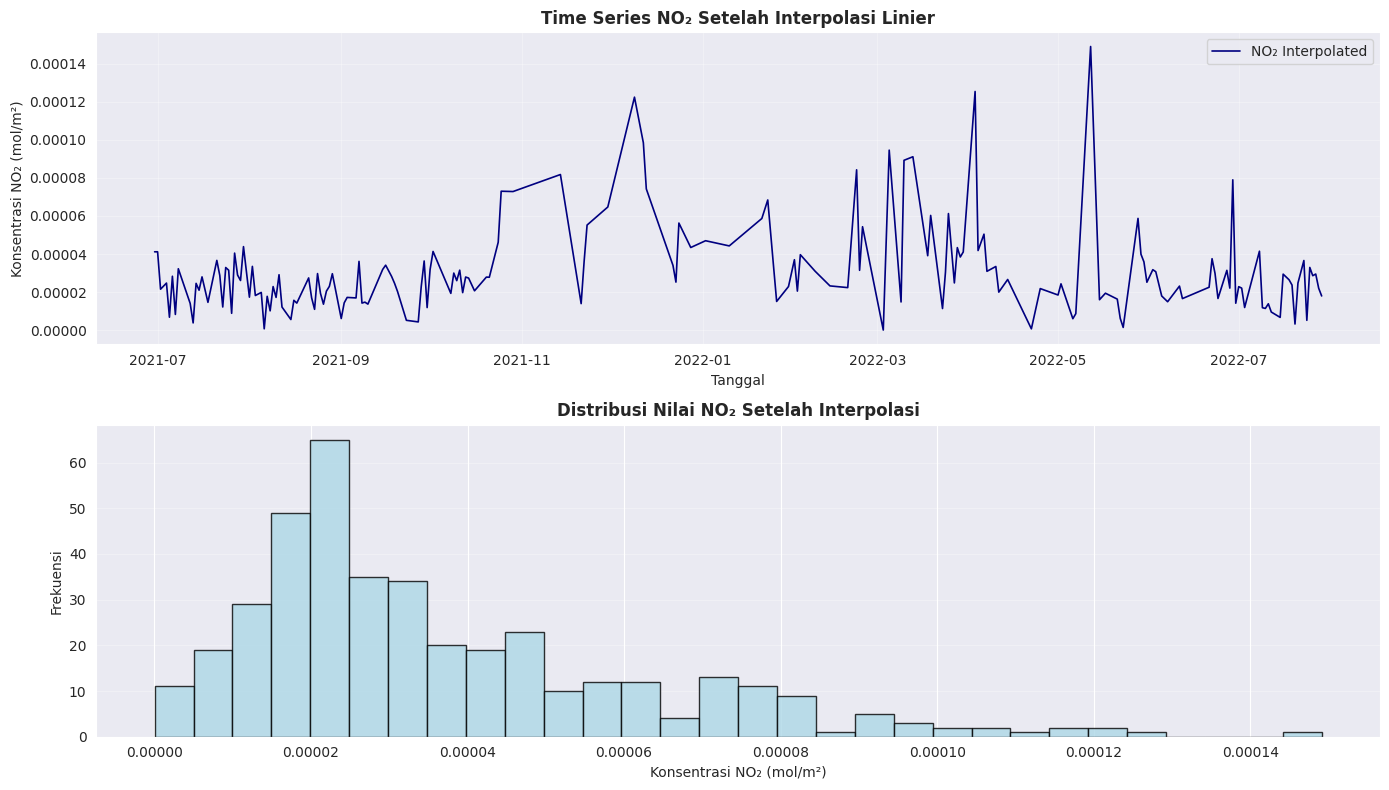


 Proses preprocessing selesai dengan sukses!


In [3]:
# ======================== LANGKAH 2: PREPROCESSING - INTERPOLASI ==========================
print("\n" + "-"*70)
print("LANGKAH 2: PROSES PREPROCESSING DATA (INTERPOLASI NILAI HILANG)")
print("-"*70)

# Membaca dataset
data = pd.read_csv("timeseries.csv")
data["date"] = pd.to_datetime(data["date"])
data = data.sort_values(by="date").reset_index(drop=True)

# Mengecek jumlah nilai hilang sebelum interpolasi
n_missing_before = data["NO2"].isnull().sum()
persen_missing = (n_missing_before / len(data)) * 100
print(f"\nJumlah nilai hilang sebelum interpolasi: {n_missing_before} ({persen_missing:.2f}%)")

# Melakukan interpolasi linier dan pengisian nilai ujung
data["NO2"] = data["NO2"].interpolate(method="linear")
data["NO2"].fillna(method="ffill", inplace=True)
data["NO2"].fillna(method="bfill", inplace=True)

# Mengecek nilai hilang setelah interpolasi
n_missing_after = data["NO2"].isnull().sum()
print(f"Jumlah nilai hilang sesudah interpolasi: {n_missing_after}")

# Menampilkan ringkasan statistik
print("\nStatistik deskriptif nilai NO₂ setelah proses interpolasi:")
print(data["NO2"].describe())

# ============================ VISUALISASI HASIL INTERPOLASI ==============================
fig, (ax1, ax2) = plt.subplots(nrows=2, figsize=(14, 8))

# Plot time series
ax1.plot(data["date"], data["NO2"], color="navy", linewidth=1.2, label="NO₂ Interpolated")
ax1.set_title("Time Series NO₂ Setelah Interpolasi Linier", fontsize=12, fontweight="bold")
ax1.set_xlabel("Tanggal")
ax1.set_ylabel("Konsentrasi NO₂ (mol/m²)")
ax1.legend()
ax1.grid(alpha=0.3)

# Plot distribusi
ax2.hist(data["NO2"], bins=30, color="lightblue", edgecolor="black", alpha=0.8)
ax2.set_title("Distribusi Nilai NO₂ Setelah Interpolasi", fontsize=12, fontweight="bold")
ax2.set_xlabel("Konsentrasi NO₂ (mol/m²)")
ax2.set_ylabel("Frekuensi")
ax2.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

print("\n Proses preprocessing selesai dengan sukses!")


### 3. Konversi Ke Supervised Learning

In [5]:
# ======================= LANGKAH 3: KONVERSI KE SUPERVISED LEARNING =======================
print("\n" + "-"*70)
print("LANGKAH 3: TRANSFORMASI DATA TIME SERIES KE MODEL SUPERVISED LEARNING")
print("-"*70)

def convert_to_supervised(dataset, n_past=1, n_future=1, remove_na=True):
    """
    Mengubah data deret waktu (time series) menjadi format supervised learning.
    Contoh: memprediksi NO2(t) berdasarkan NO2(t-1), NO2(t-2), dst.
    """
    df_temp = pd.DataFrame(dataset)
    frame_list, col_labels = [], []

    # Membuat kolom input (lag)
    for step in range(n_past, 0, -1):
        frame_list.append(df_temp.shift(step))
        col_labels.append(f"NO2(t-{step})")

    # Membuat kolom output (nilai target)
    for step in range(0, n_future):
        frame_list.append(df_temp.shift(-step))
        if step == 0:
            col_labels.append("NO2(t)")
        else:
            col_labels.append(f"NO2(t+{step})")

    # Gabungkan semua kolom
    merged = pd.concat(frame_list, axis=1)
    merged.columns = col_labels

    # Hapus baris dengan nilai NaN (karena hasil pergeseran)
    if remove_na:
        merged.dropna(inplace=True)

    return merged

# Gunakan 3 lag (t-1, t-2, t-3)
lag_count = 3
supervised_data = convert_to_supervised(data[["NO2"]], n_past=lag_count, n_future=1)

print(f"\nData berhasil diubah menjadi format supervised learning dengan lag = {lag_count}")
print(f"  • Total sampel : {len(supervised_data)}")
print(f"  • Jumlah fitur : {lag_count} (dari t-1 sampai t-{lag_count})")
print(f"  • Jumlah target: 1 (yaitu NO2(t))")
print("\nContoh 5 data pertama:")
print(supervised_data.head())



----------------------------------------------------------------------
LANGKAH 3: TRANSFORMASI DATA TIME SERIES KE MODEL SUPERVISED LEARNING
----------------------------------------------------------------------

Data berhasil diubah menjadi format supervised learning dengan lag = 3
  • Total sampel : 392
  • Jumlah fitur : 3 (dari t-1 sampai t-3)
  • Jumlah target: 1 (yaitu NO2(t))

Contoh 5 data pertama:
   NO2(t-3)  NO2(t-2)  NO2(t-1)    NO2(t)
3  0.000041  0.000041  0.000021  0.000023
4  0.000041  0.000021  0.000023  0.000025
5  0.000021  0.000023  0.000025  0.000007
6  0.000023  0.000025  0.000007  0.000028
7  0.000025  0.000007  0.000028  0.000008


### 4. Normalisasi Data Menggunakan Standard Scaler


----------------------------------------------------------------------
LANGKAH 4: PROSES NORMALISASI DATA MENGGUNAKAN STANDARD SCALER
----------------------------------------------------------------------

Metode Normalisasi yang digunakan: StandardScaler (Z-score)
  • Rumus: (x - mean) / std
  • Rentang hasil: dari -∞ sampai +∞
  • Hasil akhir memiliki mean ≈ 0 dan standar deviasi ≈ 1

Ringkasan statistik SEBELUM normalisasi:
           NO2(t-3)      NO2(t-2)      NO2(t-1)        NO2(t)
count  3.920000e+02  3.920000e+02  3.920000e+02  3.920000e+02
mean   3.658312e-05  3.655327e-05  3.650436e-05  3.649532e-05
std    2.543669e-05  2.543816e-05  2.544769e-05  2.545366e-05
min    2.094412e-08  2.094412e-08  2.094412e-08  2.094412e-08
25%    1.916454e-05  1.916454e-05  1.916454e-05  1.901708e-05
50%    2.882796e-05  2.882796e-05  2.865034e-05  2.865034e-05
75%    4.705907e-05  4.705907e-05  4.705907e-05  4.705907e-05
max    1.491192e-04  1.491192e-04  1.491192e-04  1.491192e-04

Normalisa

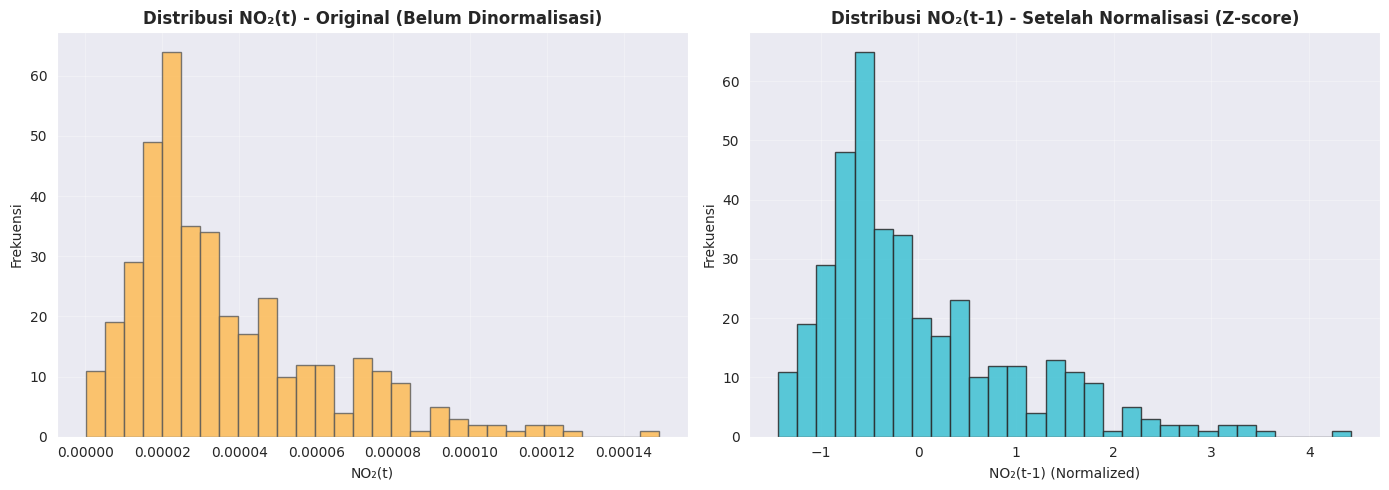


 Tahap normalisasi selesai dengan sukses!


In [6]:
# ============================= LANGKAH 4: NORMALISASI DATA ==============================
print("\n" + "-"*70)
print("LANGKAH 4: PROSES NORMALISASI DATA MENGGUNAKAN STANDARD SCALER")
print("-"*70)

# Inisialisasi StandardScaler (Z-score normalization)
z_scaler = StandardScaler()

print("\nMetode Normalisasi yang digunakan: StandardScaler (Z-score)")
print("  • Rumus: (x - mean) / std")
print("  • Rentang hasil: dari -∞ sampai +∞")
print("  • Hasil akhir memiliki mean ≈ 0 dan standar deviasi ≈ 1")

# Statistik sebelum normalisasi
print("\nRingkasan statistik SEBELUM normalisasi:")
print(supervised_data.describe())

# Pisahkan fitur (input) dan target
X_input = supervised_data.iloc[:, :-1]  # Kolom t-1, t-2, t-3
y_output = supervised_data.iloc[:, -1]  # Kolom target t

# Fit scaler hanya pada fitur input
z_scaler.fit(X_input)

# Transformasi data fitur
X_scaled = z_scaler.transform(X_input)

# Konversi kembali ke DataFrame agar mudah dibaca
norm_data = pd.DataFrame(X_scaled, columns=X_input.columns)

# Catatan: Kolom target (NO2(t)) tidak ikut dinormalisasi
print("\nNormalisasi selesai! (hanya pada fitur input)")
print("\nRingkasan statistik SESUDAH normalisasi:")
print(norm_data.describe())

# ============================== VISUALISASI HASIL =======================================
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Histogram sebelum normalisasi
ax1.hist(
    supervised_data["NO2(t)"],
    bins=30,
    color="#FFB84C",  # warna orange lembut
    edgecolor="#5A5A5A",
    alpha=0.8
)
ax1.set_title("Distribusi NO₂(t) - Original (Belum Dinormalisasi)", fontsize=12, fontweight="bold")
ax1.set_xlabel("NO₂(t)")
ax1.set_ylabel("Frekuensi")
ax1.grid(alpha=0.3)

# Histogram sesudah normalisasi
ax2.hist(
    norm_data["NO2(t-1)"],
    bins=30,
    color="#3EC1D3",  # biru toska cerah
    edgecolor="#2A2A2A",
    alpha=0.85
)
ax2.set_title("Distribusi NO₂(t-1) - Setelah Normalisasi (Z-score)", fontsize=12, fontweight="bold")
ax2.set_xlabel("NO₂(t-1) (Normalized)")
ax2.set_ylabel("Frekuensi")
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

print("\n Tahap normalisasi selesai dengan sukses!")


### 5. Definisikan Batas Ambang (Threshold) dan Buat Labels


LANGKAH 5: DEFINISIKAN THRESHOLD DAN BUAT LABELS

Threshold Definition:
  - Menggunakan: 75th percentile
  - Nilai threshold: 0.00004706 mol/m²

  - Label 0 (AMAN):      NO2 ≤ 0.00004706
  - Label 1 (BERBAHAYA): NO2 > 0.00004706

Distribusi Label:
  - Label 0 (AMAN):      294 samples (75.0%)
  - Label 1 (BERBAHAYA): 98 samples (25.0%)


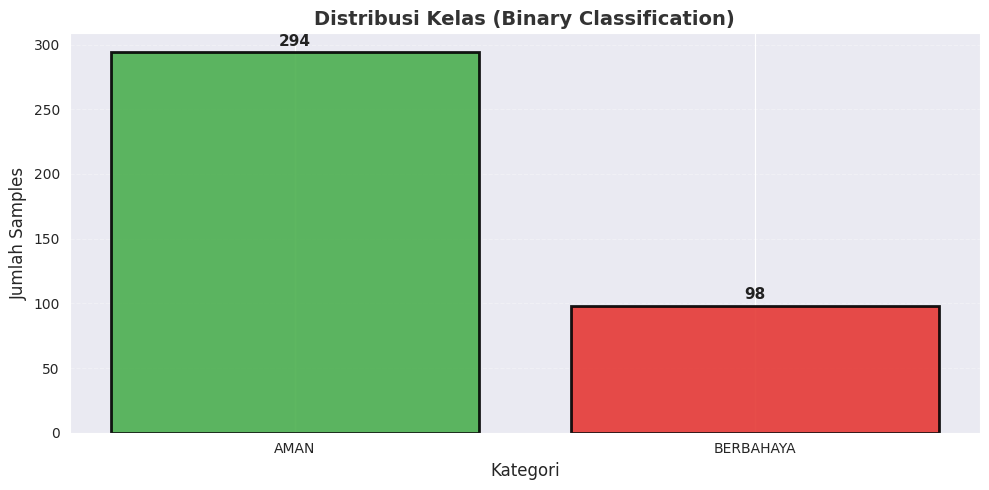


 Labels berhasil dibuat dan ditambahkan ke dataset normalisasi!


In [7]:
print("\n" + "="*70)
print("LANGKAH 5: DEFINISIKAN THRESHOLD DAN BUAT LABELS")
print("="*70)

# Gunakan 75th percentile sebagai threshold
threshold = supervised_data["NO2(t)"].quantile(0.75)

print(f"\nThreshold Definition:")
print(f"  - Menggunakan: 75th percentile")
print(f"  - Nilai threshold: {threshold:.8f} mol/m²")
print(f"\n  - Label 0 (AMAN):      NO2 ≤ {threshold:.8f}")
print(f"  - Label 1 (BERBAHAYA): NO2 > {threshold:.8f}")

# Buat binary labels untuk data asli (belum dinormalisasi)
binary_labels = (supervised_data["NO2(t)"] > threshold).astype(int)

# Tambahkan kolom label ke data yang sudah dinormalisasi (norm_data)
norm_data_with_labels = norm_data.copy()
norm_data_with_labels["label"] = binary_labels.values

# ======================================================
# 3️⃣ Tampilkan statistik distribusi label
# ======================================================
print(f"\nDistribusi Label:")
label_counts = norm_data_with_labels["label"].value_counts().sort_index()
print(f"  - Label 0 (AMAN):      {label_counts[0]} samples ({label_counts[0]/len(norm_data_with_labels)*100:.1f}%)")
print(f"  - Label 1 (BERBAHAYA): {label_counts[1]} samples ({label_counts[1]/len(norm_data_with_labels)*100:.1f}%)")

# ======================================================
# 4️⃣ Visualisasi distribusi label
# ======================================================
fig, ax = plt.subplots(figsize=(10, 5))

labels_text = ['AMAN', 'BERBAHAYA']
colors_bar = ['#4CAF50', '#E53935']  # hijau lembut & merah terang
bars = ax.bar(labels_text, label_counts.values, 
              color=colors_bar, alpha=0.85, edgecolor='black', linewidth=2)

# Tambahkan efek visual
for bar in bars:
    bar.set_linewidth(2)
    bar.set_alpha(0.9)

# Judul dan label
ax.set_title('Distribusi Kelas (Binary Classification)', fontsize=14, fontweight='bold', color="#333")
ax.set_ylabel('Jumlah Samples', fontsize=12)
ax.set_xlabel('Kategori', fontsize=12)
ax.grid(axis='y', linestyle='--', alpha=0.3)

# Tampilkan nilai di atas bar
for i, v in enumerate(label_counts.values):
    ax.text(i, v + 5, f"{v}", ha='center', fontweight='bold', fontsize=11, color="#222")

plt.tight_layout()
plt.show()

print("\n Labels berhasil dibuat dan ditambahkan ke dataset normalisasi!")


### Modelling

### 6. Pemodelan KNN Regression


 LANGKAH 6: PEMODELAN KNN REGRESSION 

 Ringkasan Data:
  • Jumlah fitur input : 3 (lag: t-1, t-2, t-3)
  • Jumlah total sampel: 392
  • Rentang nilai target NO₂: 0.00000002 – 0.00014912 mol/m²

 Pembagian Data:
  • Data latih : 313 sampel (79.8%)
  • Data uji   : 79 sampel (20.2%)

---------------------------------------------------------------------------
  UJI COBA: VARIASI NILAI K PADA KNN REGRESSION
---------------------------------------------------------------------------
  ➤ K=2  | RMSE=0.00001909 | MAE=0.00001286 | R²=0.1558
  ➤ K=3  | RMSE=0.00001749 | MAE=0.00001114 | R²=0.2917
  ➤ K=5  | RMSE=0.00001678 | MAE=0.00001024 | R²=0.3478
  ➤ K=7  | RMSE=0.00001633 | MAE=0.00000977 | R²=0.3819
  ➤ K=9  | RMSE=0.00001566 | MAE=0.00000932 | R²=0.4317
  ➤ K=11 | RMSE=0.00001553 | MAE=0.00000938 | R²=0.4413

 Hasil Terbaik:
  • K optimal      : 11
  • RMSE terkecil  : 0.00001553
  • R² Score       : 0.4413


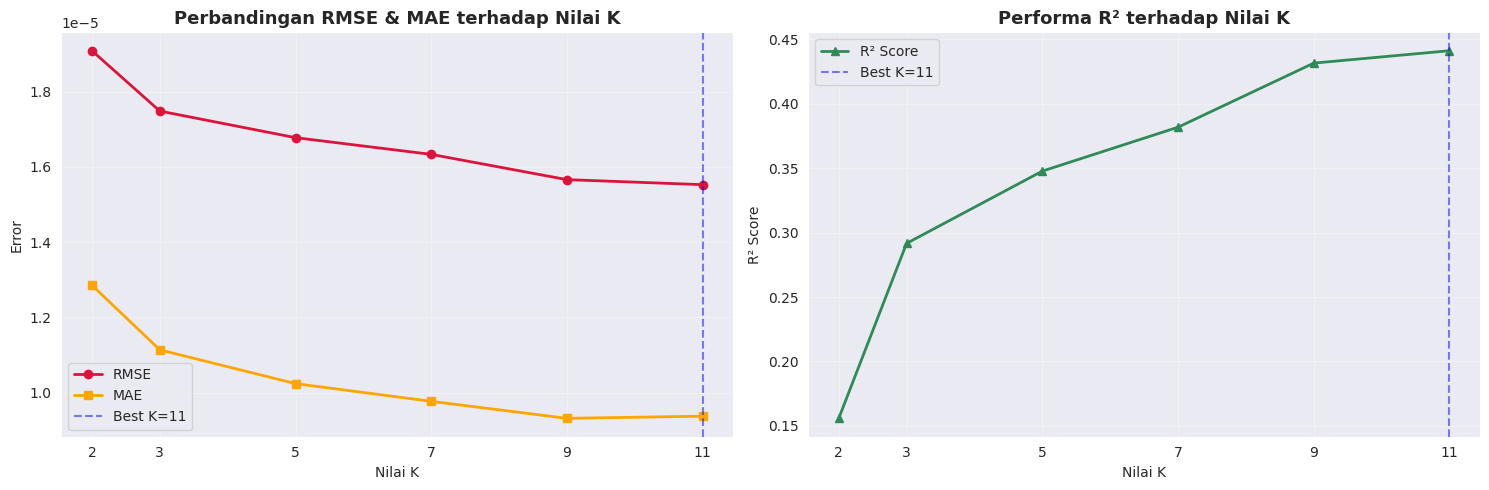


 Proses KNN Regression selesai! Model terbaik menggunakan K = 11


In [8]:
print("\n" + "="*75)
print(" LANGKAH 6: PEMODELAN KNN REGRESSION ")
print("="*75)

from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import train_test_split

# ========================== PERSIAPAN DATA ==========================
# Gunakan data hasil normalisasi (fitur input) dan target asli (NO2(t))
X = norm_data.values           # fitur hasil normalisasi (t-1, t-2, t-3)
y = supervised_data["NO2(t)"].values  # target asli (belum dinormalisasi)

print("\n Ringkasan Data:")
print(f"  • Jumlah fitur input : {X.shape[1]} (lag: t-1, t-2, t-3)")
print(f"  • Jumlah total sampel: {len(X)}")
print(f"  • Rentang nilai target NO₂: {y.min():.8f} – {y.max():.8f} mol/m²")

# Pembagian data (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, shuffle=False
)

print("\n Pembagian Data:")
print(f"  • Data latih : {len(X_train)} sampel ({len(X_train)/len(X)*100:.1f}%)")
print(f"  • Data uji   : {len(X_test)} sampel ({len(X_test)/len(X)*100:.1f}%)")

# ========================== EKSPERIMEN NILAI K ==========================
k_values = [2, 3, 5, 7, 9, 11]
print("\n" + "-"*75)
print("  UJI COBA: VARIASI NILAI K PADA KNN REGRESSION")
print("-"*75)

results_k = []
for k in k_values:
    knn_model = KNeighborsRegressor(n_neighbors=k, metric='euclidean')
    knn_model.fit(X_train, y_train)
    y_pred = knn_model.predict(X_test)

    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    results_k.append({
        'k': k,
        'RMSE': rmse,
        'MAE': mae,
        'R²': r2
    })

    print(f"  ➤ K={k:<2d} | RMSE={rmse:.8f} | MAE={mae:.8f} | R²={r2:.4f}")

# Simpan hasil ke DataFrame
results_k_df = pd.DataFrame(results_k)

# Tentukan K terbaik (berdasarkan RMSE terkecil)
best_idx = results_k_df['RMSE'].idxmin()
best_k = int(results_k_df.loc[best_idx, 'k'])
best_rmse = results_k_df.loc[best_idx, 'RMSE']
best_r2 = results_k_df.loc[best_idx, 'R²']

print("\n Hasil Terbaik:")
print(f"  • K optimal      : {best_k}")
print(f"  • RMSE terkecil  : {best_rmse:.8f}")
print(f"  • R² Score       : {best_r2:.4f}")

# ========================== VISUALISASI HASIL ==========================
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Plot RMSE dan MAE
axes[0].plot(results_k_df['k'], results_k_df['RMSE'], 'o-', lw=2, color='crimson', label='RMSE')
axes[0].plot(results_k_df['k'], results_k_df['MAE'], 's-', lw=2, color='orange', label='MAE')
axes[0].axvline(best_k, color='blue', linestyle='--', alpha=0.5, label=f'Best K={best_k}')
axes[0].set_title('Perbandingan RMSE & MAE terhadap Nilai K', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Nilai K')
axes[0].set_ylabel('Error')
axes[0].legend()
axes[0].grid(alpha=0.3)
axes[0].set_xticks(k_values)

# Plot R²
axes[1].plot(results_k_df['k'], results_k_df['R²'], '^-', lw=2, color='seagreen', label='R² Score')
axes[1].axvline(best_k, color='blue', linestyle='--', alpha=0.5, label=f'Best K={best_k}')
axes[1].set_title('Performa R² terhadap Nilai K', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Nilai K')
axes[1].set_ylabel('R² Score')
axes[1].legend()
axes[1].grid(alpha=0.3)
axes[1].set_xticks(k_values)

plt.tight_layout()
plt.show()

print(f"\n Proses KNN Regression selesai! Model terbaik menggunakan K = {best_k}")


### 7. Evaluasi Regression & Penerapan Threshold


 LANGKAH 7: EVALUASI REGRESSION & PENERAPAN THRESHOLD 

 [A] METRIK REGRESI (K = 11):
  • MSE   : 0.0000000002
  • RMSE  : 0.0000155291
  • MAE   : 0.0000093762
  • R²    : 0.4413

 [B] METRIK KLASIFIKASI (Setelah Threshold):
  • Threshold   : 0.00004706 mol/m²
  • Accuracy    : 0.9241
  • Precision   : 0.5000
  • Recall      : 0.5000
  • F1-Score    : 0.5000

Confusion Matrix Detail:
  • True Negatives  (AMAN → AMAN)           : 70
  • False Positives (AMAN → BERBAHAYA)     : 3
  • False Negatives (BERBAHAYA → AMAN)     : 3
  • True Positives  (BERBAHAYA → BERBAHAYA): 3


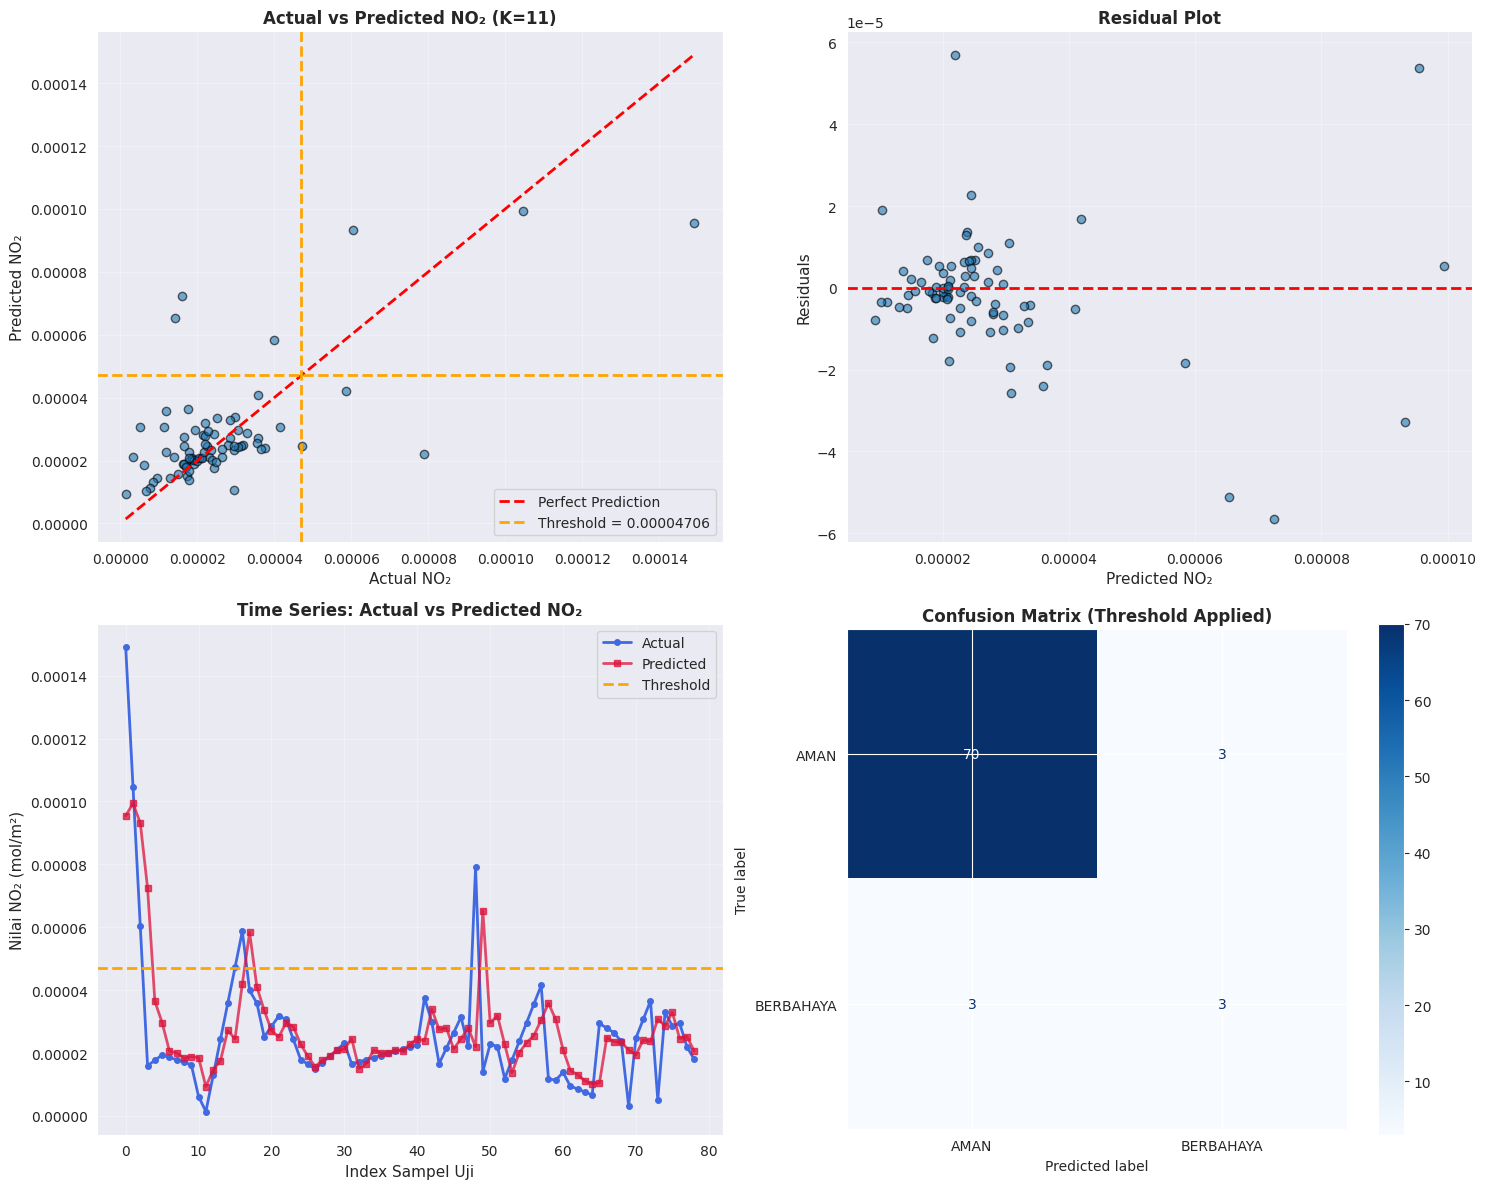


 Classification Report:
              precision    recall  f1-score   support

        AMAN       0.96      0.96      0.96        73
   BERBAHAYA       0.50      0.50      0.50         6

    accuracy                           0.92        79
   macro avg       0.73      0.73      0.73        79
weighted avg       0.92      0.92      0.92        79


 Evaluasi selesai — model KNN Regression (K=11) berhasil dievaluasi!


In [9]:
print("\n" + "="*75)
print(" LANGKAH 7: EVALUASI REGRESSION & PENERAPAN THRESHOLD ")
print("="*75)

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, ConfusionMatrixDisplay, classification_report
)

# ==================== LATIH MODEL AKHIR DENGAN K TERBAIK ====================
final_model = KNeighborsRegressor(n_neighbors=int(best_k), metric='euclidean')
final_model.fit(X_train, y_train)

# ==================== PREDIKSI NILAI NO2 (KONTINU) ====================
y_pred_regression = final_model.predict(X_test)

# Hitung metrik regresi
mse = mean_squared_error(y_test, y_pred_regression)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred_regression)
r2 = r2_score(y_test, y_pred_regression)

print(f"\n [A] METRIK REGRESI (K = {best_k}):")
print(f"  • MSE   : {mse:.10f}")
print(f"  • RMSE  : {rmse:.10f}")
print(f"  • MAE   : {mae:.10f}")
print(f"  • R²    : {r2:.4f}")

# ==================== PENERAPAN THRESHOLD ====================
y_test_binary = (y_test > threshold).astype(int)
y_pred_binary = (y_pred_regression > threshold).astype(int)

# Hitung metrik klasifikasi
accuracy  = accuracy_score(y_test_binary, y_pred_binary)
precision = precision_score(y_test_binary, y_pred_binary, zero_division=0)
recall    = recall_score(y_test_binary, y_pred_binary, zero_division=0)
f1        = f1_score(y_test_binary, y_pred_binary, zero_division=0)

print(f"\n [B] METRIK KLASIFIKASI (Setelah Threshold):")
print(f"  • Threshold   : {threshold:.8f} mol/m²")
print(f"  • Accuracy    : {accuracy:.4f}")
print(f"  • Precision   : {precision:.4f}")
print(f"  • Recall      : {recall:.4f}")
print(f"  • F1-Score    : {f1:.4f}")

# Confusion matrix
cm = confusion_matrix(y_test_binary, y_pred_binary)
tn, fp, fn, tp = cm.ravel()

print(f"\nConfusion Matrix Detail:")
print(f"  • True Negatives  (AMAN → AMAN)           : {tn}")
print(f"  • False Positives (AMAN → BERBAHAYA)     : {fp}")
print(f"  • False Negatives (BERBAHAYA → AMAN)     : {fn}")
print(f"  • True Positives  (BERBAHAYA → BERBAHAYA): {tp}")

# ==================== VISUALISASI ====================
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# (1) Scatter: Actual vs Predicted
axes[0, 0].scatter(y_test, y_pred_regression, alpha=0.6, edgecolors='k')
axes[0, 0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()],
                'r--', lw=2, label='Perfect Prediction')
axes[0, 0].axhline(y=threshold, color='orange', linestyle='--', lw=2)
axes[0, 0].axvline(x=threshold, color='orange', linestyle='--', lw=2,
                   label=f'Threshold = {threshold:.8f}')
axes[0, 0].set_xlabel('Actual NO₂', fontsize=11)
axes[0, 0].set_ylabel('Predicted NO₂', fontsize=11)
axes[0, 0].set_title(f'Actual vs Predicted NO₂ (K={best_k})', fontsize=12, fontweight='bold')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# (2) Residual Plot
residuals = y_test - y_pred_regression
axes[0, 1].scatter(y_pred_regression, residuals, alpha=0.6, edgecolors='k')
axes[0, 1].axhline(y=0, color='r', linestyle='--', lw=2)
axes[0, 1].set_xlabel('Predicted NO₂', fontsize=11)
axes[0, 1].set_ylabel('Residuals', fontsize=11)
axes[0, 1].set_title('Residual Plot', fontsize=12, fontweight='bold')
axes[0, 1].grid(True, alpha=0.3)

# (3) Time Series Comparison
test_idx = range(len(y_test))
axes[1, 0].plot(test_idx, y_test, label='Actual', color='royalblue', linewidth=2, marker='o', markersize=4)
axes[1, 0].plot(test_idx, y_pred_regression, label='Predicted', color='crimson', linewidth=2, marker='s', markersize=4, alpha=0.75)
axes[1, 0].axhline(y=threshold, color='orange', linestyle='--', linewidth=2, label='Threshold')
axes[1, 0].set_xlabel('Index Sampel Uji', fontsize=11)
axes[1, 0].set_ylabel('Nilai NO₂ (mol/m²)', fontsize=11)
axes[1, 0].set_title('Time Series: Actual vs Predicted NO₂', fontsize=12, fontweight='bold')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# (4) Confusion Matrix Plot
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['AMAN', 'BERBAHAYA'])
disp.plot(ax=axes[1, 1], cmap='Blues', values_format='d')
axes[1, 1].set_title('Confusion Matrix (Threshold Applied)', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

# ==================== LAPORAN AKHIR ====================
print("\n Classification Report:")
print(classification_report(y_test_binary, y_pred_binary, target_names=['AMAN', 'BERBAHAYA']))

print(f"\n Evaluasi selesai — model KNN Regression (K={best_k}) berhasil dievaluasi!")


### 8. Visualisasi - Prediction Analysis


LANGKAH 8: VISUALIsasi - PREDICTION ANALYSIS

Error Analysis:
  - Mean Absolute Error : 0.00000938
  - Median Absolute Error: 0.00000511
  - Max Error           : 0.00005704
  - Min Error           : 0.00000009


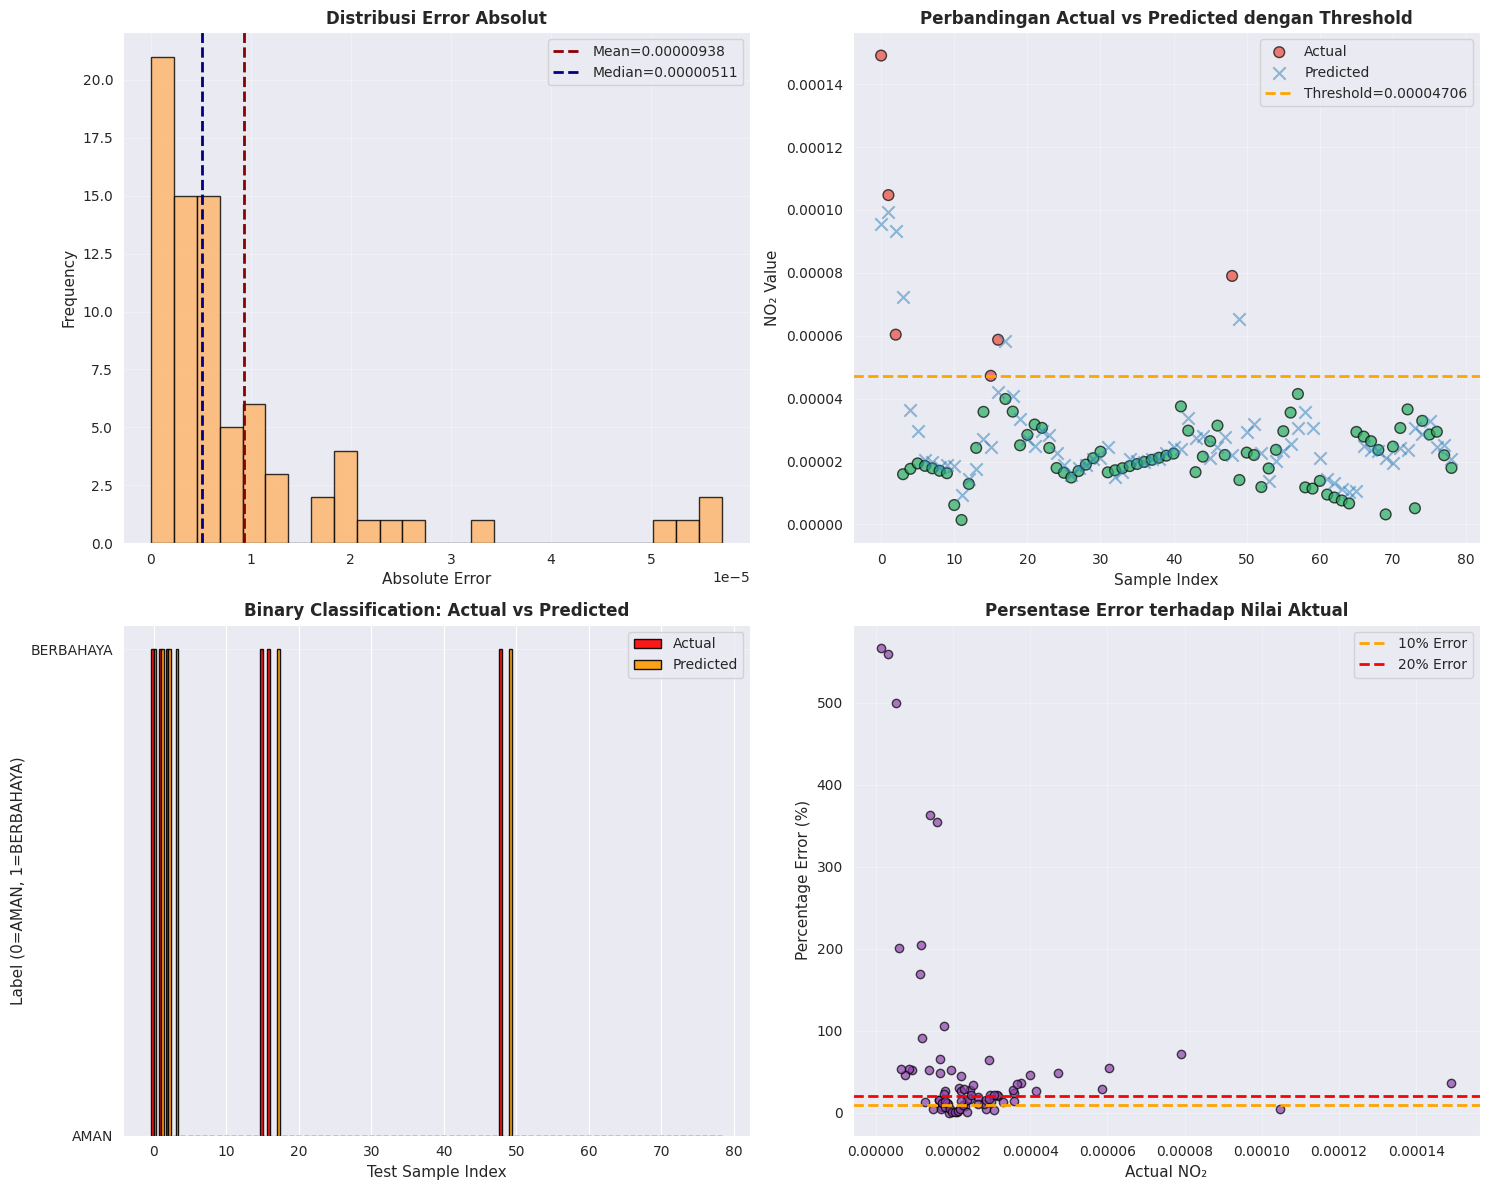


 Visualisasi analisis prediksi selesai.


In [10]:
print("\n" + "="*70)
print("LANGKAH 8: VISUALIsasi - PREDICTION ANALYSIS")
print("="*70)

# Analisis error distribution
errors = np.abs(y_test - y_pred_regression)
mean_error = np.mean(errors)
median_error = np.median(errors)

print(f"\nError Analysis:")
print(f"  - Mean Absolute Error : {mean_error:.8f}")
print(f"  - Median Absolute Error: {median_error:.8f}")
print(f"  - Max Error           : {errors.max():.8f}")
print(f"  - Min Error           : {errors.min():.8f}")

# ============================================================
# VISUALISASI
# ============================================================
fig, axes = plt.subplots(2, 2, figsize=(15, 12))
plt.subplots_adjust(hspace=0.3, wspace=0.25)

#  Plot 1: Error Distribution
axes[0, 0].hist(errors, bins=25, edgecolor='black', alpha=0.8, color='#ffb366')
axes[0, 0].axvline(x=mean_error, color='darkred', linestyle='--', linewidth=2, label=f'Mean={mean_error:.8f}')
axes[0, 0].axvline(x=median_error, color='navy', linestyle='--', linewidth=2, label=f'Median={median_error:.8f}')
axes[0, 0].set_xlabel('Absolute Error', fontsize=11)
axes[0, 0].set_ylabel('Frequency', fontsize=11)
axes[0, 0].set_title('Distribusi Error Absolut', fontsize=12, fontweight='bold')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

#  Plot 2: Prediction vs Actual dengan Threshold
colors_scatter = ['#27ae60' if val <= threshold else '#e74c3c' for val in y_test]
axes[0, 1].scatter(range(len(y_test)), y_test, alpha=0.7, label='Actual', c=colors_scatter, edgecolors='k', s=60)
axes[0, 1].scatter(range(len(y_pred_regression)), y_pred_regression, alpha=0.5, label='Predicted', marker='x', s=80, c='#2980b9')
axes[0, 1].axhline(y=threshold, color='orange', linestyle='--', linewidth=2, label=f'Threshold={threshold:.8f}')
axes[0, 1].set_xlabel('Sample Index', fontsize=11)
axes[0, 1].set_ylabel('NO₂ Value', fontsize=11)
axes[0, 1].set_title('Perbandingan Actual vs Predicted dengan Threshold', fontsize=12, fontweight='bold')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

#  Plot 3: Binary Classification Result (warna kontras)
x_pos = np.arange(len(y_test_binary))
width = 0.35

# Gunakan warna yang benar-benar kontras dan mudah dibedakan
colors_actual = ['#0055ff' if x == 0 else '#ff0000' for x in y_test_binary]  # Biru & Merah terang
colors_pred = ['#33cc33' if x == 0 else '#ff9900' for x in y_pred_binary]    # Hijau & Oranye terang

axes[1, 0].bar(
    x_pos - width/2, y_test_binary, width, label='Actual',
    color=colors_actual, alpha=0.9, edgecolor='black'
)
axes[1, 0].bar(
    x_pos + width/2, y_pred_binary, width, label='Predicted',
    color=colors_pred, alpha=0.9, edgecolor='black'
)
axes[1, 0].set_xlabel('Test Sample Index', fontsize=11)
axes[1, 0].set_ylabel('Label (0=AMAN, 1=BERBAHAYA)', fontsize=11)
axes[1, 0].set_title('Binary Classification: Actual vs Predicted', fontsize=12, fontweight='bold')
axes[1, 0].set_yticks([0, 1])
axes[1, 0].set_yticklabels(['AMAN', 'BERBAHAYA'])
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3, axis='y')

#  Plot 4: Percentage Error
percentage_error = (errors / y_test) * 100
axes[1, 1].scatter(y_test, percentage_error, alpha=0.7, edgecolors='k', c='#8e44ad')
axes[1, 1].axhline(y=10, color='orange', linestyle='--', linewidth=2, label='10% Error')
axes[1, 1].axhline(y=20, color='red', linestyle='--', linewidth=2, label='20% Error')
axes[1, 1].set_xlabel('Actual NO₂', fontsize=11)
axes[1, 1].set_ylabel('Percentage Error (%)', fontsize=11)
axes[1, 1].set_title('Persentase Error terhadap Nilai Aktual', fontsize=12, fontweight='bold')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\n Visualisasi analisis prediksi selesai.")


### 9. Memprediksi Nilai NO2 Satu Hari Ke Depan


LANGKAH 9: MEMPREDIKSI NILAI NO₂ SATU HARI KE DEPAN

Data 3 hari terakhir (Original):
  - NO₂(t-3): 0.00002859 mol/m²
  - NO₂(t-2): 0.00002947 mol/m²
  - NO₂(t-1): 0.00002200 mol/m²

Data 3 hari terakhir (Normalized):
  - NO₂(t-3): -0.3145
  - NO₂(t-2): -0.2788
  - NO₂(t-1): -0.5707

HASIL PREDIKSI NO₂ HARI BESOK (SATU HARI KE DEPAN)

[A] PREDIKSI NILAI NO₂ (Regression):
  - Predicted NO₂ : 0.00002065 mol/m²

[B] THRESHOLD APPLICATION:
  - Threshold      : 0.00004706 mol/m²
  - Status         : AMAN
  - Difference     : -0.00002641 mol/m²
  - Percentage     : -56.12% dari threshold

✔ AMAN: NO₂ diprediksi 56.1% di bawah threshold.
   → Kualitas udara dalam kondisi aman.


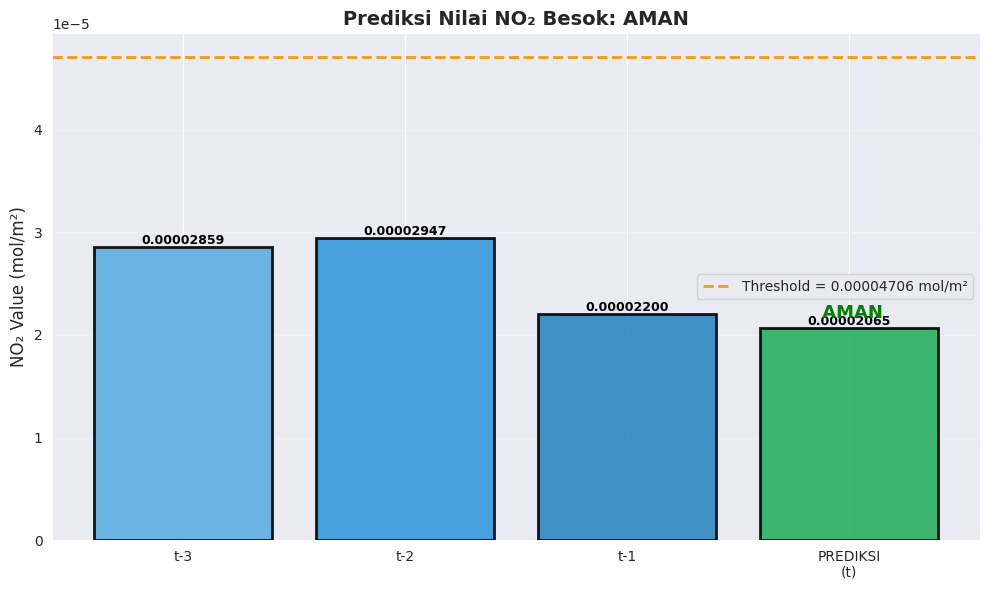


Prediksi selesai dan divisualisasikan dengan sukses!


In [54]:
print("\n" + "="*70)
print("LANGKAH 9: MEMPREDIKSI NILAI NO₂ SATU HARI KE DEPAN")
print("="*70)

# Ambil 3 hari terakhir dari supervised_data (data asli)
last_3_days_original = supervised_data[["NO2(t-3)", "NO2(t-2)", "NO2(t-1)"]].iloc[-1].values

print(f"\nData 3 hari terakhir (Original):")
print(f"  - NO₂(t-3): {last_3_days_original[0]:.8f} mol/m²")
print(f"  - NO₂(t-2): {last_3_days_original[1]:.8f} mol/m²")
print(f"  - NO₂(t-1): {last_3_days_original[2]:.8f} mol/m²")

# Normalisasi menggunakan z_scaler
last_3_days_scaled = z_scaler.transform([last_3_days_original])[0]

print(f"\nData 3 hari terakhir (Normalized):")
print(f"  - NO₂(t-3): {last_3_days_scaled[0]:.4f}")
print(f"  - NO₂(t-2): {last_3_days_scaled[1]:.4f}")
print(f"  - NO₂(t-1): {last_3_days_scaled[2]:.4f}")

# Siapkan data untuk prediksi
X_tomorrow = last_3_days_scaled.reshape(1, -1)

# Prediksi nilai NO₂ besok
pred_no2_value = final_model.predict(X_tomorrow)[0]

# Tentukan status berdasarkan threshold
pred_status = 'BERBAHAYA' if pred_no2_value > threshold else 'AMAN'
difference_from_threshold = pred_no2_value - threshold
percentage_diff = (difference_from_threshold / threshold) * 100

print("\n" + "="*70)
print("HASIL PREDIKSI NO₂ HARI BESOK (SATU HARI KE DEPAN)")
print("="*70)
print(f"\n[A] PREDIKSI NILAI NO₂ (Regression):")
print(f"  - Predicted NO₂ : {pred_no2_value:.8f} mol/m²")

print(f"\n[B] THRESHOLD APPLICATION:")
print(f"  - Threshold      : {threshold:.8f} mol/m²")
print(f"  - Status         : {pred_status}")
print(f"  - Difference     : {difference_from_threshold:.8f} mol/m²")
print(f"  - Percentage     : {percentage_diff:+.2f}% dari threshold")

# Peringatan berdasarkan kondisi
if pred_status == 'BERBAHAYA':
    if percentage_diff > 20:
        print(f"\n⚠ PERINGATAN TINGGI: NO₂ diprediksi {percentage_diff:.1f}% DI ATAS threshold!")
        print(f"   → Prediksi SANGAT BERBAHAYA, segera ambil tindakan pencegahan!")
    elif percentage_diff > 10:
        print(f"\n⚠ PERINGATAN SEDANG: NO₂ diprediksi {percentage_diff:.1f}% di atas threshold.")
        print(f"   → Status BERBAHAYA, waspadai kualitas udara!")
    else:
        print(f"\n⚠ PERINGATAN: NO₂ diprediksi {percentage_diff:.1f}% di atas threshold.")
        print(f"   → Status BERBAHAYA, perlu monitoring rutin.")
else:
    if abs(percentage_diff) < 5:
        print(f"\n✔ HATI-HATI: NO₂ diprediksi hanya {abs(percentage_diff):.1f}% DI BAWAH threshold.")
        print(f"   → Status masih AMAN, namun mendekati batas ambang!")
    else:
        print(f"\n✔ AMAN: NO₂ diprediksi {abs(percentage_diff):.1f}% di bawah threshold.")
        print(f"   → Kualitas udara dalam kondisi aman.")

# ============================================================
# VISUALISASI
# ============================================================
fig, ax = plt.subplots(figsize=(10, 6))

# Data untuk visualisasi
days = ['t-3', 't-2', 't-1', 'PREDIKSI\n(t)']
values = list(last_3_days_original) + [pred_no2_value]

# 🎨 Warna batang lebih kontras dan berbeda
colors_bar = ['#5DADE2', '#3498DB', '#2E86C1', '#E74C3C' if pred_status == 'BERBAHAYA' else '#27AE60']

bars = ax.bar(
    days, values, color=colors_bar, alpha=0.9,
    edgecolor='black', linewidth=2, zorder=3
)

# Garis threshold
ax.axhline(
    y=threshold, color='#F39C12', linestyle='--',
    linewidth=2, label=f'Threshold = {threshold:.8f} mol/m²', zorder=2
)

# Label dan judul
ax.set_ylabel('NO₂ Value (mol/m²)', fontsize=12)
ax.set_title(f'Prediksi Nilai NO₂ Besok: {pred_status}', fontsize=14, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3, axis='y', zorder=0)

# Tambahkan label nilai di atas bar
for bar, val in zip(bars, values):
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width()/2, height + (0.00003 * threshold),
        f'{val:.8f}', ha='center', va='bottom',
        fontsize=9, fontweight='bold', color='black'
    )

# Tambahkan teks status besar di atas bar terakhir
status_text = " BERBAHAYA" if pred_status == "BERBAHAYA" else " AMAN"
status_color = 'red' if pred_status == 'BERBAHAYA' else 'green'

ax.text(
    len(days) - 1, pred_no2_value * 1.05,
    status_text,
    color=status_color,
    fontsize=13, fontweight='bold', ha='center'
)

plt.tight_layout()
plt.show()

print("\n" + "="*70)
print("Prediksi selesai dan divisualisasikan dengan sukses!")
print("="*70)
